In [1]:
import sys
from pathlib import Path

from analysis.aggregations import agg_contribution_score_by_role_relative

REPO_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *
from analysis.uuid_extractor import *

## Jupyter notes

## Multiple runs: Load and transform run

In [2]:
data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"

# Optional: set a timestamp prefix to load only matching runs, e.g. "26-02-26"
# Leave as None to load all runs under experimentData/
PREFIX = None

runs = load_runs(data_dir, prefix="31-03-26")

guids = extract_uuids_from_filenames(runs)
print(guids)

# Normalize units: wei → ETH, ratio → %
runs = normalize_runs(runs)
res = merge_runs(runs)

print(f"Loaded {len(runs)} run(s)")

['{98b7b7e9-1e72-4fc1-a460-ef07aeff3ee9}']
Loaded 1 run(s)


## Plots

## Plot: GRS by user

In [3]:
# # data[['grs', 'user_id', 'round']]
#
# vals = grs_by_user(data)
#
# fig = plot_grs_by_user(vals)


## Plot: Agg. GRS by role

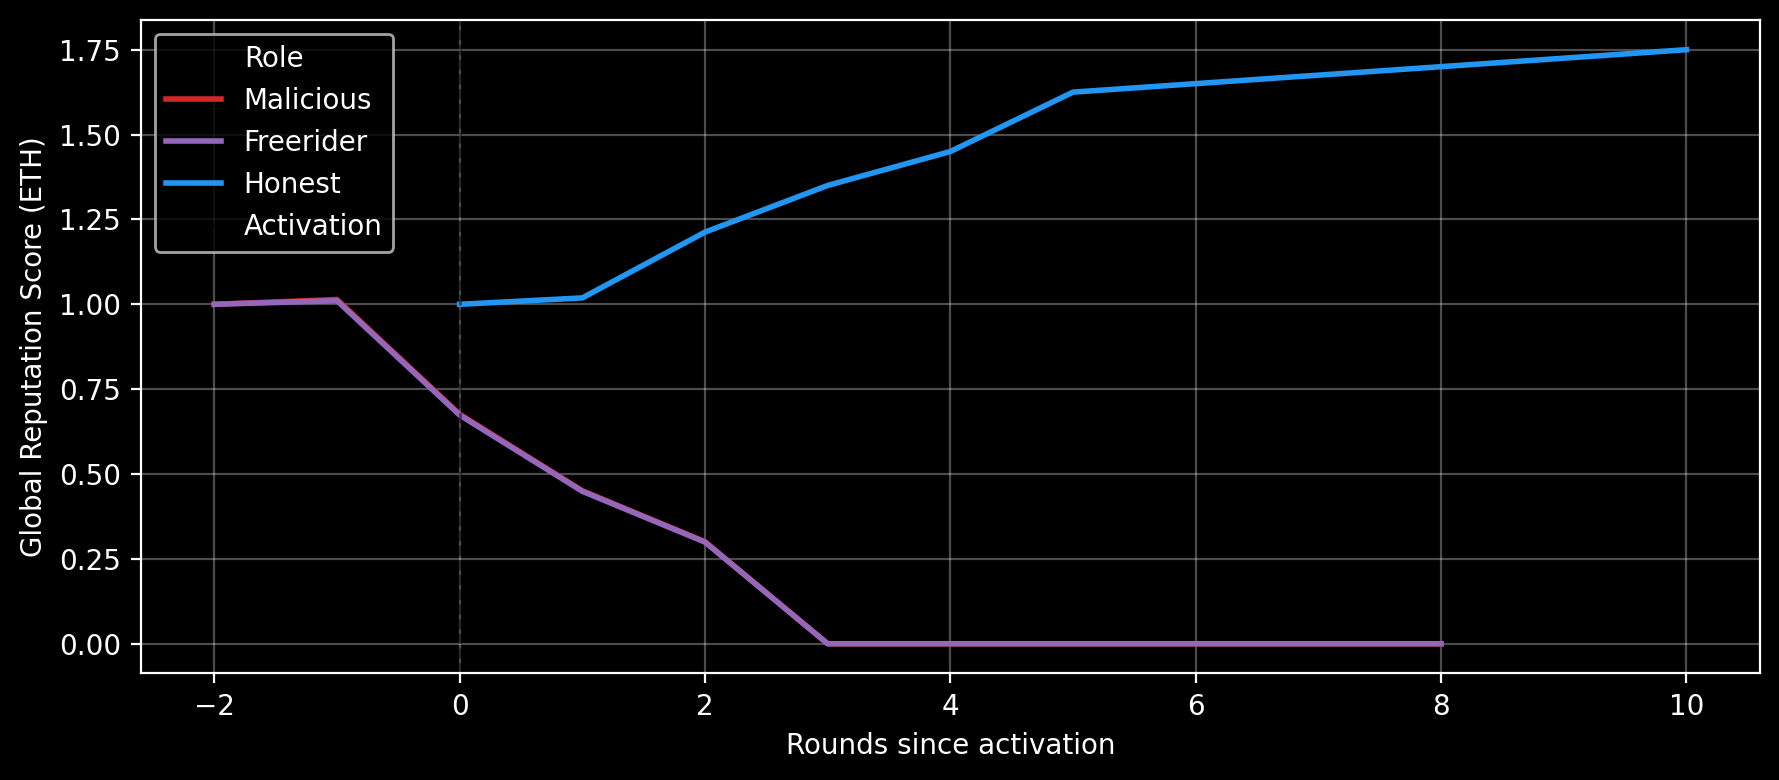

In [4]:
data = res['users']
aggregated = agg_grs_by_role_relative(data, res['metadata'])
fig = plot_grs_by_role_relative(aggregated)

# Per activation round
# Check why mal/fr falls before round 0 (since activation)

## Plot: Model Performance by Global Accuracy for aggregation strategies

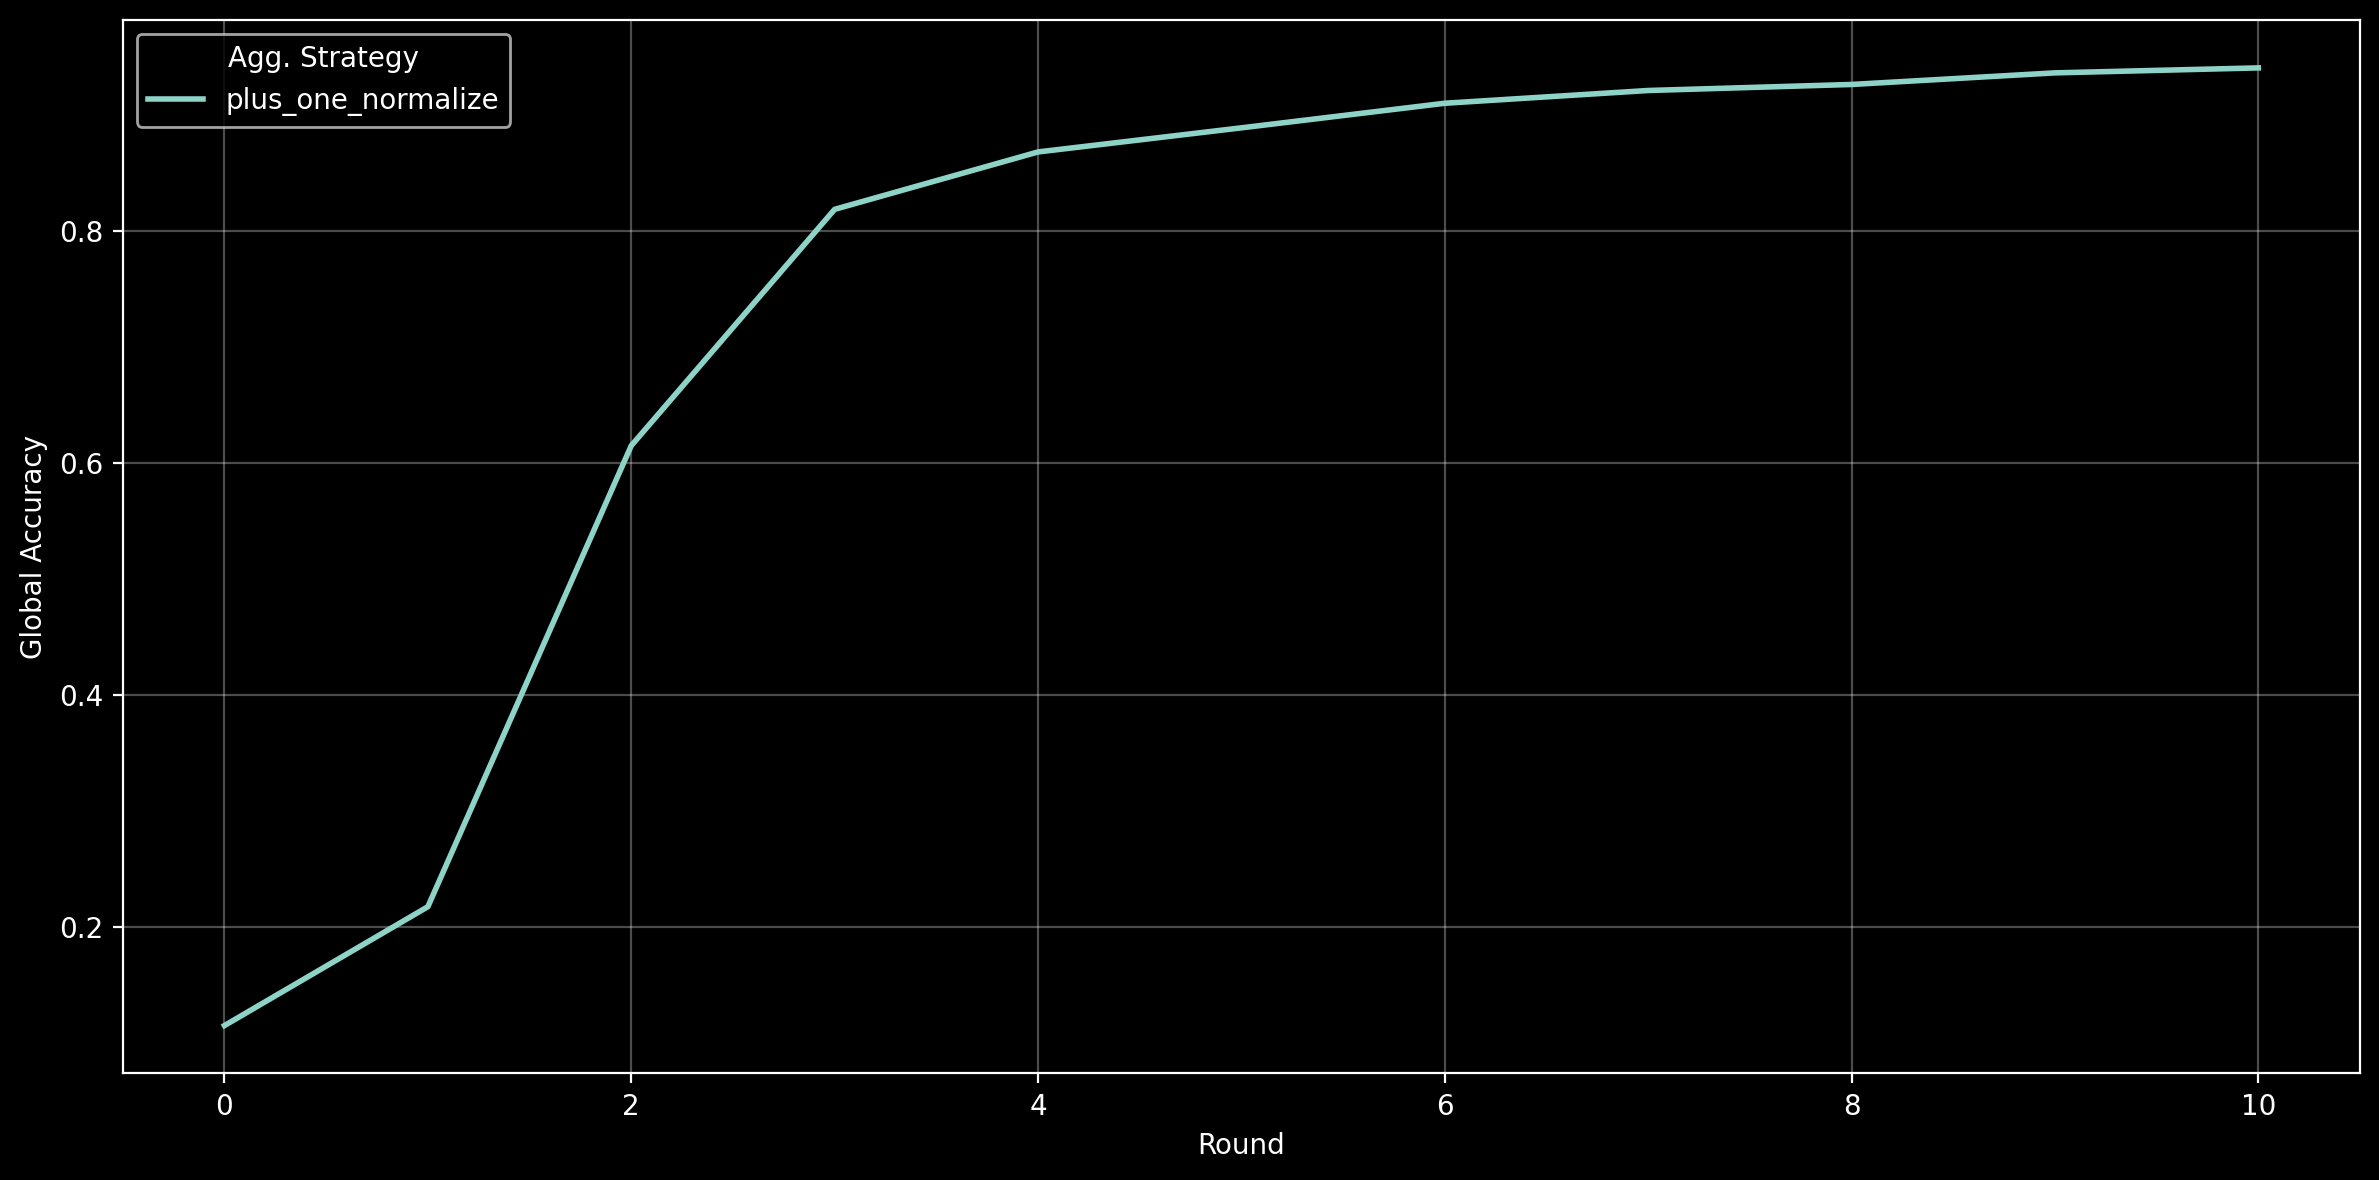

In [5]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

data = data[data['round'].between(0, 12)]

vals = global_acc_by_aggregation_strategy(data, res['metadata'])

fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

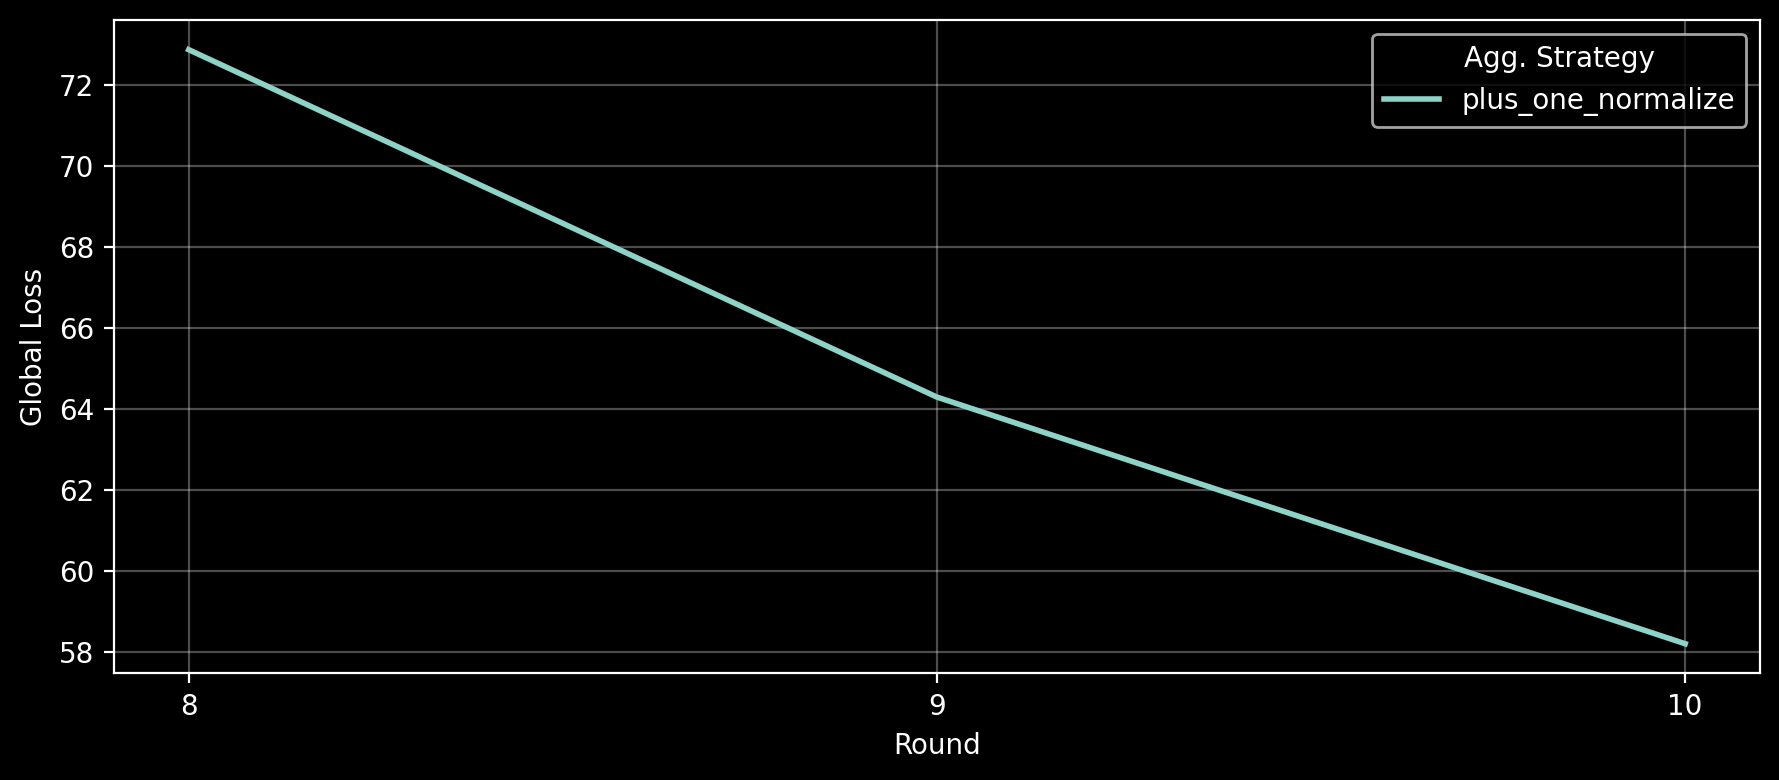

In [6]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data[['round', 'role', 'behavior', 'round_reputation_assigned', 'merged']]


data = data[data['round'].between(8, 24)]

vals = global_loss_by_aggregation_strategy(data, res['metadata'])
fig = plot_global_loss_by_aggregation_strategy(vals)

### Plot: plot_accuracy_loss_over_rounds

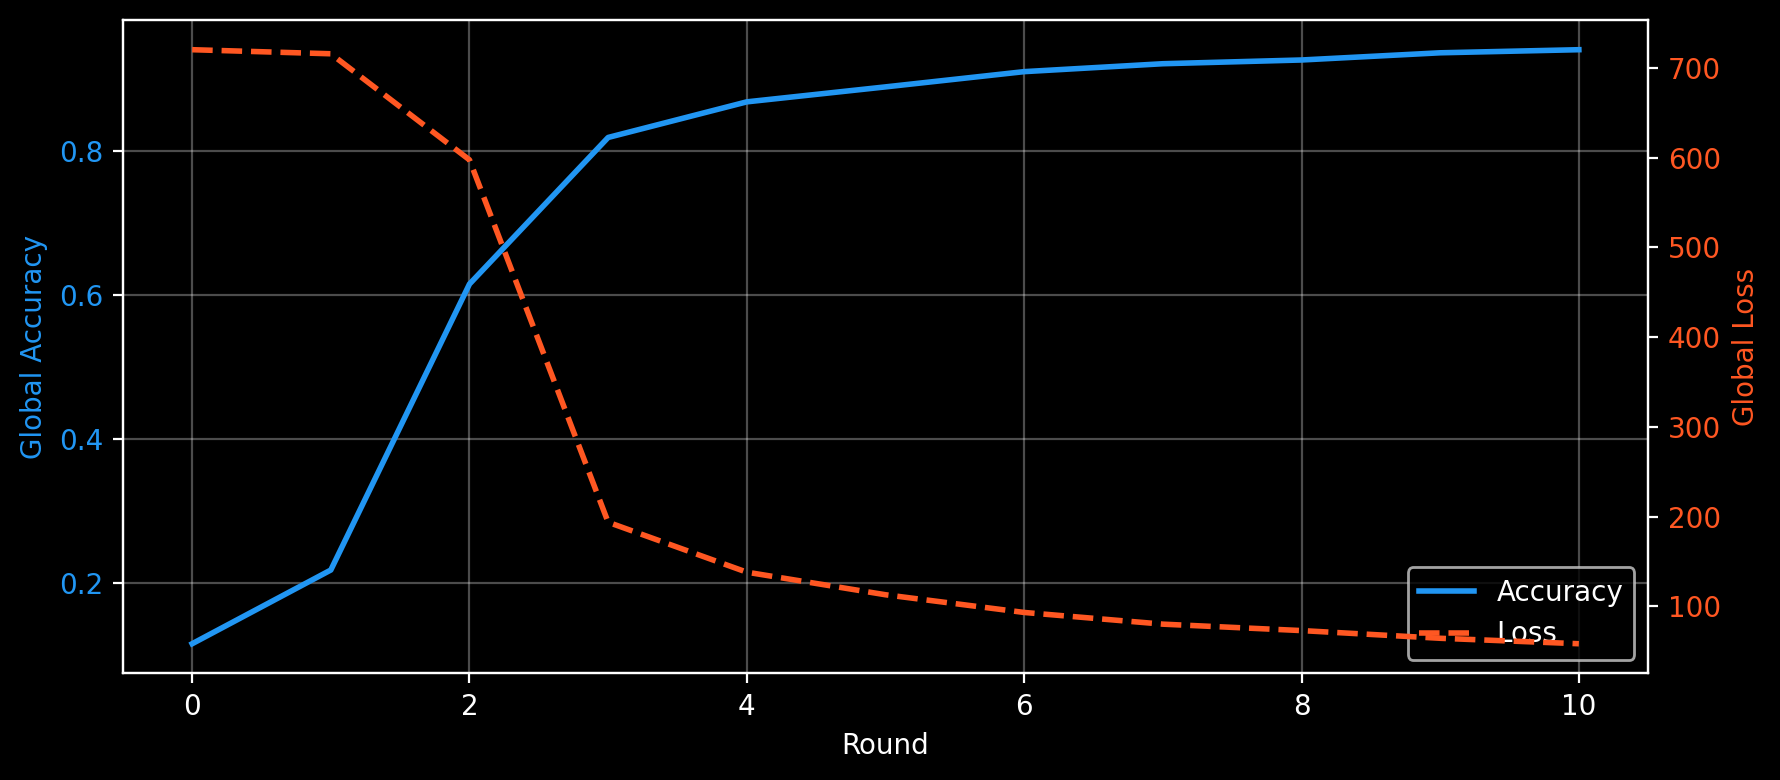

In [7]:
data = res['global']
aggregated = agg_global_accuracy_loss_by_round(data)
fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.

### Plot: plot_gas_cost_by_tx_type

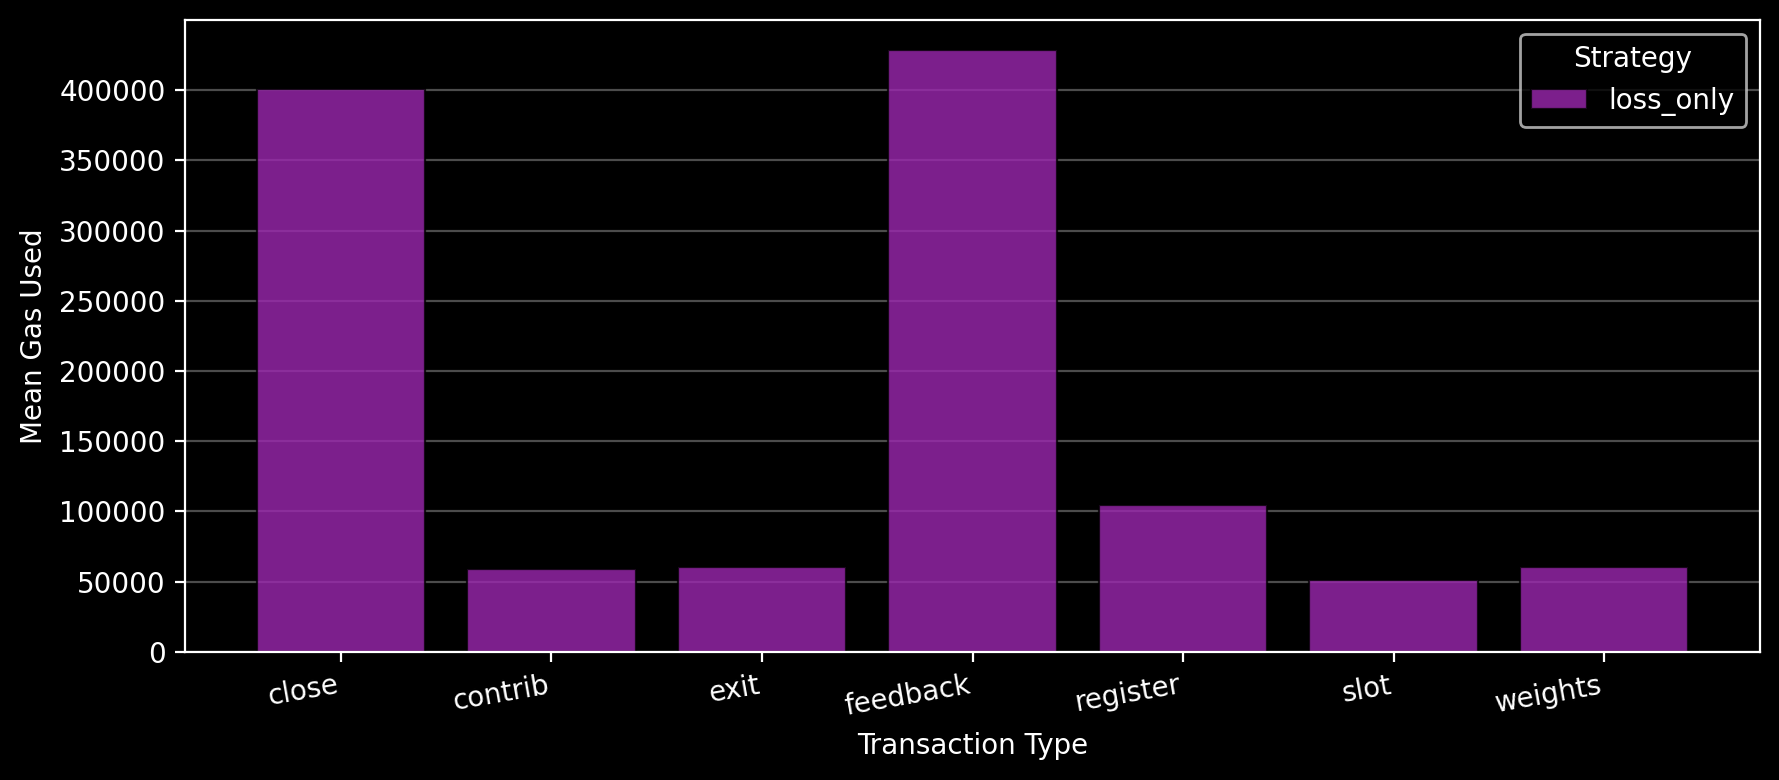

In [8]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data, res['metadata'])
fig = plot_gas_cost_by_tx_type(aggregated)

## Plot: Contribution score by role (relative)

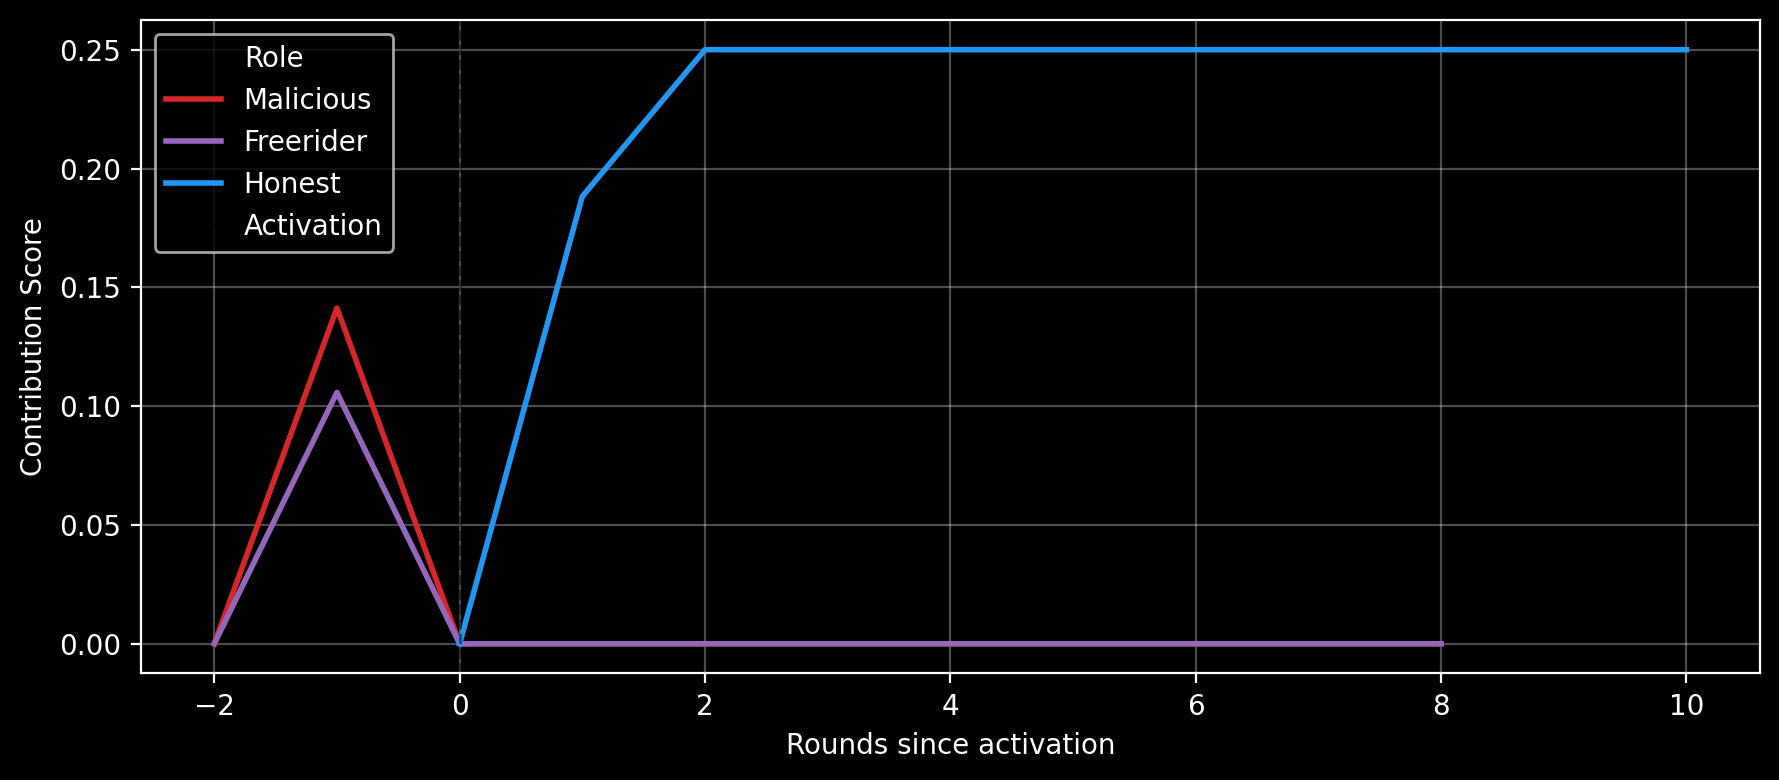

In [9]:
u = res['users']
c = res['contributions']
agg = agg_contribution_score_by_role_relative(u, c, res['metadata'])

fig = plot_contribution_score_by_role_relative(agg)

# Per activation round

## Query: Runtime warnings

In [10]:
# data = res['setup'] does not work

data = res['warnings']


res['votes']

,experiment_id,round,giver_id,receiver_id,giver_address,receiver_address,vote_feedback_score,vote_prev_accuracy,vote_prev_loss,vote_accuracy,vote_loss,is_outlier
0,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,1,0,1,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,1,1230,7364,7190,3175,False
1,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,1,0,2,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,0x9f886a6bAD6DfD9409e05eE6743184feE0338d01,0,1230,7364,6940,4068,False
2,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,1,0,3,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,-1,1230,7364,6040,6480,False
3,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,1,0,4,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,0x1930426B96FD9D0Ca399436995100315E3a37118,-1,1230,7364,6230,5074,False
4,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,1,0,5,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,0xcA8c42e4A7725bbd27d2d6911c579cc8f6d51913,1,1230,7364,7120,5634,False
...,...,...,...,...,...,...,...,...,...,...,...,...
181,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,10,1,3,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,1,9330,619,9420,609,False
182,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,10,2,1,0x9f886a6bAD6DfD9409e05eE6743184feE0338d01,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,1,9380,641,9490,627,False
183,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,10,2,3,0x9f886a6bAD6DfD9409e05eE6743184feE0338d01,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,1,9380,641,9450,634,False
184,test-mnist-loss_only-2-1.0-2-1.0-True-plus_one...,10,3,1,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,1,9450,651,9170,763,False


## Another

In [11]:
# users_data[
#       (users_data['aggregation_rule'] == 'FedAVG') &
#       (users_data['behavior'] != 'good') &
#       (users_data['merged'] == True)
#   ]

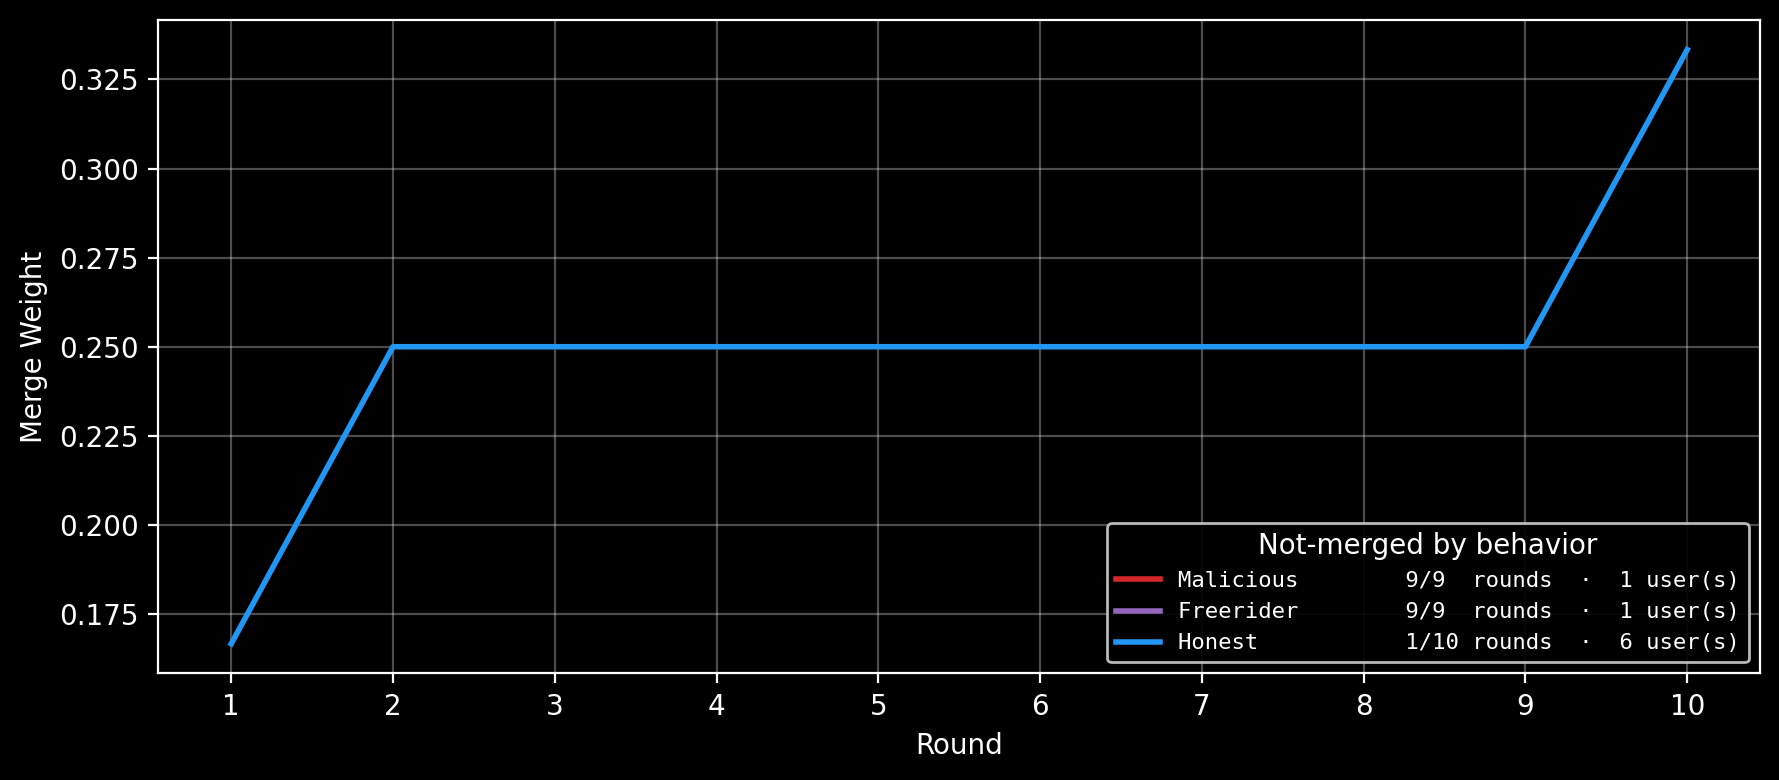

In [12]:
users_data = res['users']

metadata = res['metadata'][['experiment_id', 'aggregation_rule']]
users_data = users_data.merge(metadata, how='left', on='experiment_id')

total_runs = users_data['experiment_id'].nunique()
# users_data[users_data['merged'] == True].groupby(['aggregation_rule', 'behavior']).size() / total_runs
# users_data[users_data['merged'] == False].groupby(['aggregation_rule', 'behavior']).size()

agg_weights = agg_merge_weights_by_behavior(users_data)
agg_stats   = agg_merge_stats_by_behavior(users_data)
# # #
# # # # plot
fig = plot_merge_weights_by_behavior(agg_weights, agg_stats)

